# Classification Track — Stroke Prediction
### 23CSE301 Machine Learning Capstone — Review 1

**Dataset:** `healthcare-dataset-stroke-data.csv`
**Goal:** Predict whether a patient is likely to have a stroke (`stroke` = 0/1) from demographic and health attributes.

This notebook covers:
- **Section A** — Dataset & EDA
- **Section B** — Preprocessing & Feature Engineering
- **Section D** — Classification Track, Part A (Logistic Regression, KNN, Naive Bayes, Decision Tree, SVM)

Section C (Regression Track) is covered in a separate notebook and is out of scope here.

## Section A — Dataset & EDA

In [ ]:
### A1 — Dataset loading & audit
Load the raw CSV and report its shape, column dtypes, missing-value counts, and the target class distribution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
palette = sns.color_palette('colorblind')

RANDOM_STATE = 42

df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 5110 rows x 12 columns


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [2]:
print("Column dtypes:")
print(df.dtypes)

Column dtypes:
id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
bmi,201,3.93


In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique patient ids:", df['id'].nunique(), "out of", len(df), "rows")

Duplicate rows: 0
Unique patient ids: 5110 out of 5110 rows


In [5]:
target_counts = df['stroke'].value_counts()
target_pct = (df['stroke'].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({'count': target_counts, 'percent': target_pct})

,count,percent
stroke,,
0,4861,95.13
1,249,4.87


**Observation (A1):** The dataset has 5,110 rows and 12 columns, with no duplicate rows and a unique `id` per patient, so no row-level deduplication is needed. The only missing values are in `bmi` (201 rows, ~3.9%); every other column is fully populated. The target `stroke` is heavily imbalanced — only 249 patients (4.87%) had a stroke versus 4,861 (95.13%) who did not. This imbalance will need to be accounted for later (e.g. via `class_weight='balanced'`, stratified splitting, or resampling) and means accuracy alone will be a misleading metric — precision, recall, F1, and ROC-AUC matter much more here.

### A2 — EDA visualisations
Distribution plots for every feature, a correlation heatmap, the target distribution, and feature-vs-target scatter plots.

#### Target distribution

/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/259518126.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/259518126.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.countplot(x='stroke', data=df, palette=palette, ax=ax)


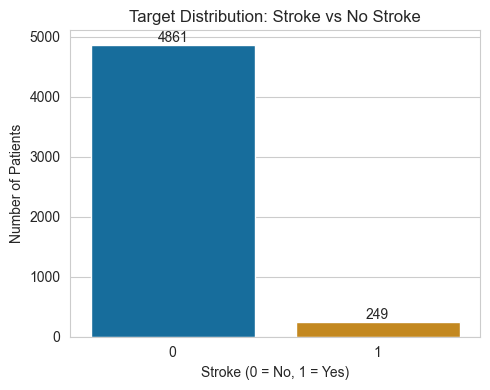

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x='stroke', data=df, palette=palette, ax=ax)
ax.set_title('Target Distribution: Stroke vs No Stroke')
ax.set_xlabel('Stroke (0 = No, 1 = Yes)')
ax.set_ylabel('Number of Patients')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Observation:** The countplot makes the class imbalance visually obvious — the no-stroke bar is roughly 20x taller than the stroke bar. This confirms A1's numeric finding and is the single most important fact shaping every modelling choice downstream in Section D.

#### Numeric feature distributions

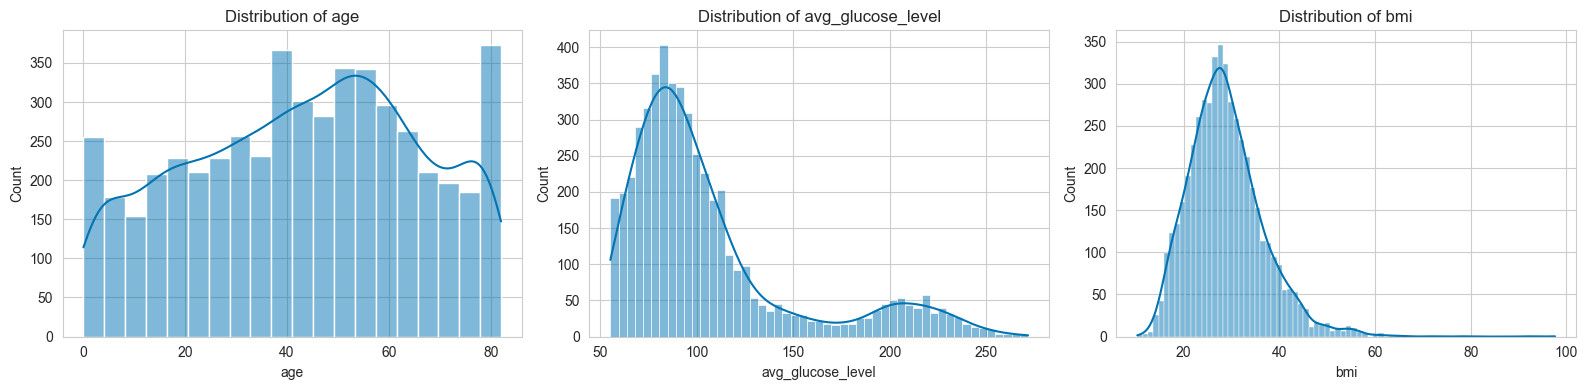

In [11]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color=palette[0])
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

**Observation:** `age` is fairly uniformly spread from 0-82 with a median around 45, reflecting a broad population sample rather than an elderly-only cohort. `avg_glucose_level` is right-skewed with a long tail past 200 mg/dL — a secondary bump above ~150 likely corresponds to diabetic/pre-diabetic patients, effectively a bimodal-looking distribution. `bmi` is roughly bell-shaped around 28-29 (overweight range by WHO cutoffs) with a long right tail of high-BMI outliers reaching into the 60-98 range, which are candidates for outlier treatment in Section B.

#### Categorical feature distributions

/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
/var/folders/44/0pqgwsjs1jn_yvghn17rmtf00000gn/T/ipykernel_72848/1648271888.py:7: User

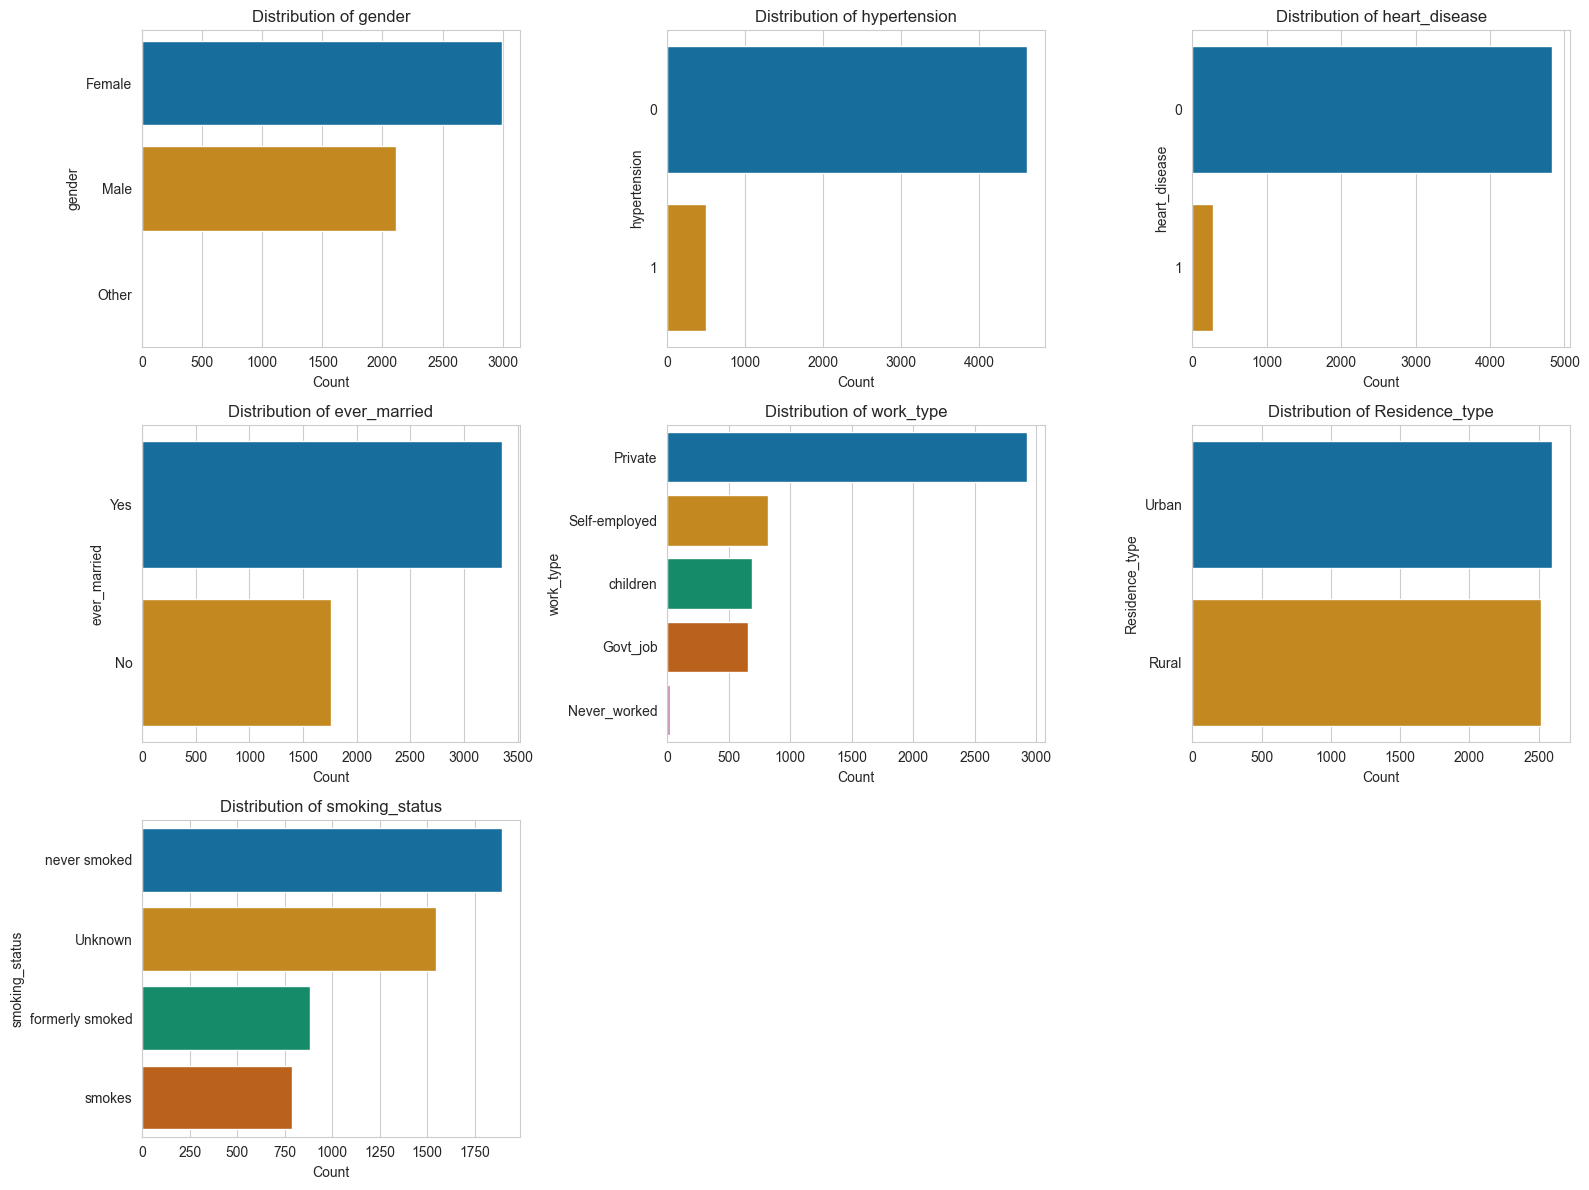

In [12]:
categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                    'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for ax, col in zip(axes, categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=col, data=df, order=order, palette=palette, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Count')
for ax in axes[len(categorical_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** `gender` is dominated by Female/Male with a single `Other` record, which is too sparse to model reliably and is a candidate for merging or dropping in Section B. `hypertension` (9.7% positive) and `heart_disease` (5.4% positive) are both rare binary conditions, similar in shape to the stroke target itself. Most patients are married (`ever_married` = Yes, 65.6%) and work in the `Private` sector, while `Never_worked` is a very small category. `Residence_type` is almost perfectly split Urban/Rural. `smoking_status` has a large `Unknown` bucket (1,544 rows, ~30%) which is effectively a fourth category rather than true missing data.

#### Correlation heatmap

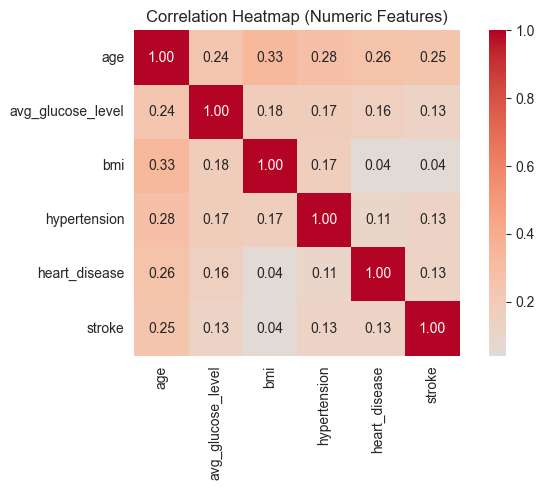

In [14]:
corr_df = df[['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

**Observation:** No feature is strongly linearly correlated with `stroke` in isolation — `age` has the strongest relationship (r ≈ 0.25), followed by `heart_disease` (≈0.13), `hypertension` (≈0.13), and `avg_glucose_level` (≈0.13); `bmi` is nearly uncorrelated (≈0.04). This is expected for a rare-event medical outcome and suggests stroke risk is driven by interactions between features (e.g. age combined with hypertension) rather than any single linear predictor — motivating the engineered interaction feature planned for Section B3 and non-linear models like Decision Trees/SVM in Section D.

#### Feature-target scatter plots

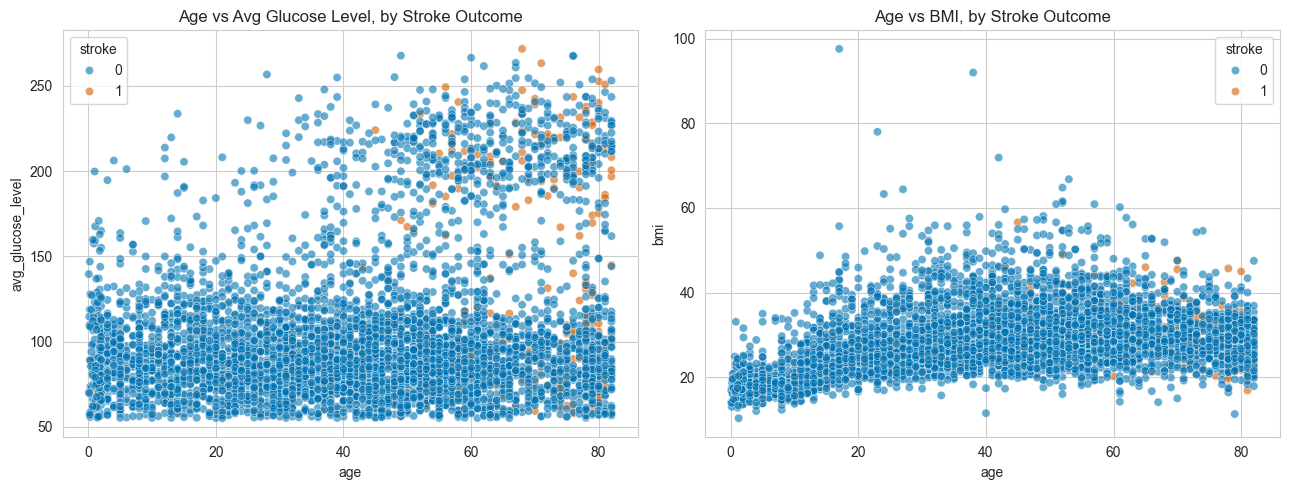

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke',
                 palette={0: palette[0], 1: palette[3]}, alpha=0.6, ax=axes[0])
axes[0].set_title('Age vs Avg Glucose Level, by Stroke Outcome')

sns.scatterplot(data=df, x='age', y='bmi', hue='stroke',
                 palette={0: palette[0], 1: palette[3]}, alpha=0.6, ax=axes[1])
axes[1].set_title('Age vs BMI, by Stroke Outcome')

plt.tight_layout()
plt.show()

**Observation:** In the Age vs Glucose plot, stroke cases (orange) are concentrated almost entirely on the right-hand side of the plot (older patients), and are noticeably denser in the elevated-glucose band above ~150 mg/dL — suggesting the combination of "older + hyperglycaemic" is a higher-risk region rather than either variable alone. In the Age vs BMI plot, stroke cases are similarly clustered at higher ages but spread across the full BMI range, reinforcing that `age` is the dominant visual driver while `bmi` on its own doesn't separate the classes — consistent with its near-zero correlation in the heatmap above.

### A3 — Insight commentary summary
Each visualisation above is paired with a written observation directly beneath it. In short: the dataset is clean (no duplicates, only `bmi` has missing values) but severely class-imbalanced (4.87% positive), `age` is the strongest single driver of stroke risk with `hypertension`/`heart_disease`/`avg_glucose_level` as secondary factors, and the scatter plots suggest risk is concentrated where older age co-occurs with elevated glucose — an interaction worth engineering explicitly in Section B.

## Section B — Preprocessing & Feature Engineering

### B1 — Data cleaning
- Drop the single `gender == 'Other'` row (too sparse — 1 out of 5,110 — to let a model learn anything from it, and it would create a category unseen in a stratified split anyway).
- Impute missing `bmi` values (median imputation, robust to the right-skew/outliers seen in Section A2), fitted on the training set only in B2.
- Check and treat `bmi` outliers using the IQR method.
- Duplicates: none were found in A1, so no action needed there.

In [16]:
print("Rows before dropping 'Other' gender:", len(df))
df = df[df['gender'] != 'Other'].reset_index(drop=True)
print("Rows after:", len(df))
print(df['gender'].value_counts())

Rows before dropping 'Other' gender: 5110
Rows after: 5109
gender
Female    2994
Male      2115
Name: count, dtype: int64


In [17]:
# Outlier check on bmi using the IQR method
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['bmi'] < lower_bound) | (df['bmi'] > upper_bound)]
print(f"BMI IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Number of bmi outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}% of rows)")

BMI IQR bounds: [9.1, 47.5]
Number of bmi outliers: 110 (2.2% of rows)


In [18]:
# Cap (winsorize) bmi outliers to the IQR bounds rather than dropping rows,
# since stroke is already rare and we don't want to lose positive cases living in the tails
df['bmi'] = df['bmi'].clip(lower=lower_bound, upper=upper_bound)
print(df['bmi'].describe())

count    4908.000000
mean       28.744804
std         7.336352
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        47.500000
Name: bmi, dtype: float64


**Observation (B1):** Clipping (winsorizing) rather than dropping outlier rows was chosen because several of the high-BMI outliers are stroke-positive cases (rare, high-value data points) — deleting them would worsen the already severe 4.87% class imbalance. Missing `bmi` values are deferred to the pipeline's imputer in B2 so imputation statistics are learned from the training fold only, avoiding leakage.